Merged dataset sample:
  GLORIA_ID Organization_ID        Dataset_ID Sample_ID LIMNADES_ID  \
0     GID_1           UT-TO  AlikasK_EE_UT-TO        53         NaN   
1     GID_2           UT-TO  AlikasK_EE_UT-TO        54         NaN   
2     GID_3           UT-TO  AlikasK_EE_UT-TO        55         NaN   
3     GID_4           UT-TO  AlikasK_EE_UT-TO        56         NaN   
4     GID_5           UT-TO  AlikasK_EE_UT-TO        57         NaN   

  LIMNADES_UID SeaBASS_ID  Data_collection_purpose  Special_event_flag  \
0          NaN        NaN                      3.0                 NaN   
1          NaN        NaN                      3.0                 NaN   
2          NaN        NaN                      3.0                 NaN   
3          NaN        NaN                      3.0                 NaN   
4          NaN        NaN                      3.0                 NaN   

     Site_name  ...   Rrs_891   Rrs_892   Rrs_893   Rrs_894   Rrs_895  \
0  Lake Peipsi  ...  0.000274  0

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_input (InputLayer)          │ (None, 551, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 549, 16)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8784)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       562,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 562,564 (2.15 MB)

 Trainable params: 562,564 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 222.8987 - mae: 8.7867 - val_loss: 106.5783 - val_mae: 6.6693
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 182.6745 - mae: 7.5409 - val_loss: 64.4078 - val_mae: 5.1505
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 125.8525 - mae: 6.3470 - val_loss: 36.3584 - val_mae: 3.9208
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 91.0254 - mae: 5.4414 - val_loss: 25.5347 - val_mae: 3.5072
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 105.3159 - mae: 5.9051 - val_loss: 29.5117 - val_mae: 3.5710
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 88.9744 - mae: 5.8317 - val_loss: 34.8704 - val_mae: 3.6370
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 118.8054 - mae: 6.4759 - val_loss: 33.2121 - val_mae: 3.6642
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 113.1740 - mae: 6.4323 - val_loss: 28.5812 - val_mae: 3.4957
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

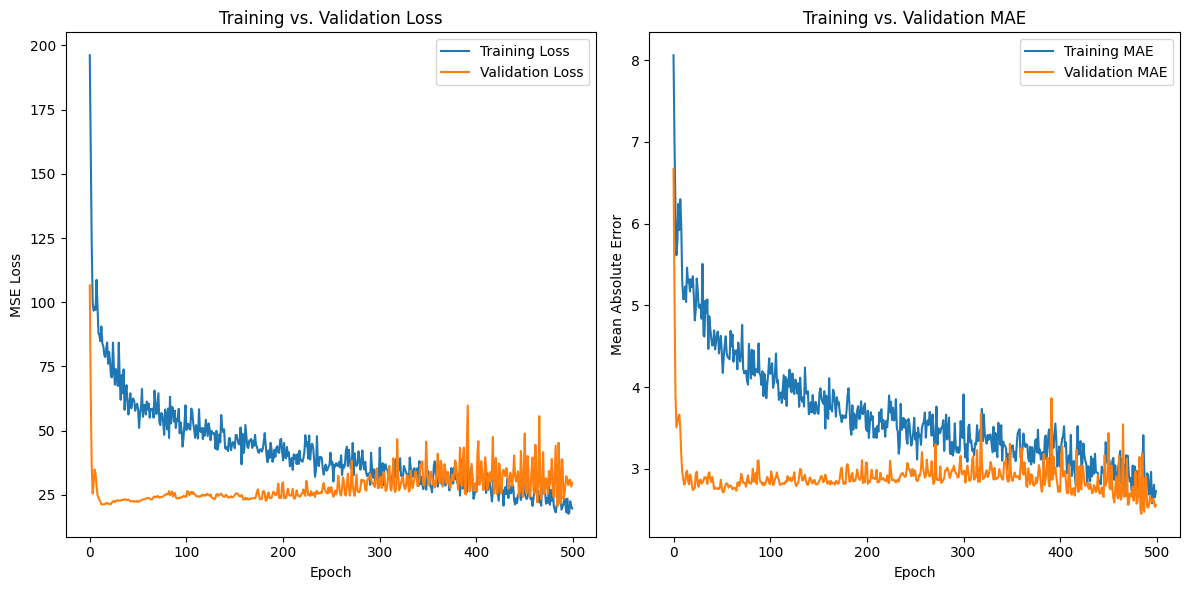

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
# ---------------------------
# Step 1: Load and Inspect Data
# ---------------------------
# File paths to the GLORIA datasets; update these paths if needed
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
rrs_data_path  = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"

# Load metadata and spectral reflectance data
meta_data = pd.read_csv(meta_data_path)
rrs_data  = pd.read_csv(rrs_data_path)

# Merge datasets on 'GLORIA_ID'
merged_data = pd.merge(meta_data, rrs_data, on='GLORIA_ID', how='inner')

print("Merged dataset sample:")
print(merged_data.head())

# ---------------------------
# Step 2: Select Features and Targets
# ---------------------------
# Define input features as all columns that start with "Rrs_"
feature_columns = [col for col in merged_data.columns if col.startswith('Rrs_')]

# Define target variables (replace "Chla" with "Chla_plus_phaeo")
target_columns = ['Chla_plus_phaeo', 'TSS', 'aCDOM440', 'Secchi_depth']

# Drop rows with missing values in selected columns
merged_data_cleaned = merged_data.dropna(subset=feature_columns + target_columns)

# Extract features (X) and targets (y)
X = merged_data_cleaned[feature_columns].values    # Spectral reflectance features
y = merged_data_cleaned[target_columns].values       # Water quality parameters

print(f"\nShape of input features (X): {X.shape}")
print(f"Shape of target variables (y): {y.shape}")

# ---------------------------
# Step 3: Preprocess the Data
# ---------------------------
# Normalize spectral features to the [0, 1] range
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# ---------------------------
# Step 4: Build the Pure CNN Model
# ---------------------------
# The CNN will process each sample’s spectral data, which needs to be reshaped 
# to have a channel dimension. For example, if there are N features, the input shape
# should be (N, 1).
input_cnn = Input(shape=(X_train.shape[1], 1), name='cnn_input')

# Add a 1D convolution layer to extract local spectral features
x = Conv1D(filters=16, kernel_size=3, activation='relu')(input_cnn)
x = Flatten()(x)

# Add fully-connected layers with dropout for regularization
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer: the number of neurons equals the number of target parameters
output = Dense(y_train.shape[1], name='output')(x)

# Define and compile the CNN model
model = Model(inputs=input_cnn, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

# ---------------------------
# Step 5: Prepare Data and Train the Model
# ---------------------------
# Reshape X_train and X_test to add the channel dimension required by Conv1D
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0],  X_test.shape[1], 1)

# Train the model
history = model.fit(
    X_train_cnn, y_train,
    epochs=500,
    batch_size=20,
    validation_split=0.2,
    verbose=1
)

print("\nTraining complete!")

# ---------------------------
# Step 6: Evaluate Model Performance
# ---------------------------
loss, mae = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTest Loss (MSE): {loss}, Test MAE: {mae}")

# ---------------------------
# Step 7: Visualize Training History and Results
# ---------------------------
plt.figure(figsize=(12, 6))

# Plot training vs. validation loss (MSE) over epochs
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs. Validation Loss')

# Plot training vs. validation MAE over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training vs. Validation MAE')

plt.tight_layout()
plt.show()
# test


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


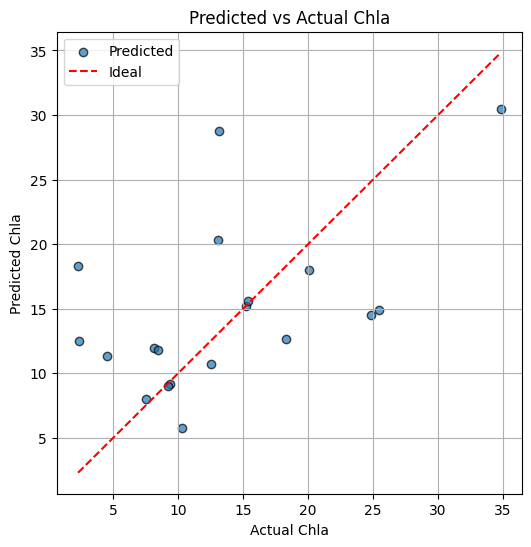

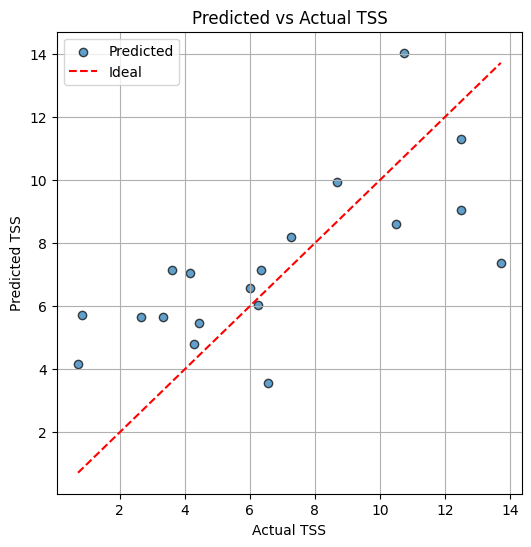

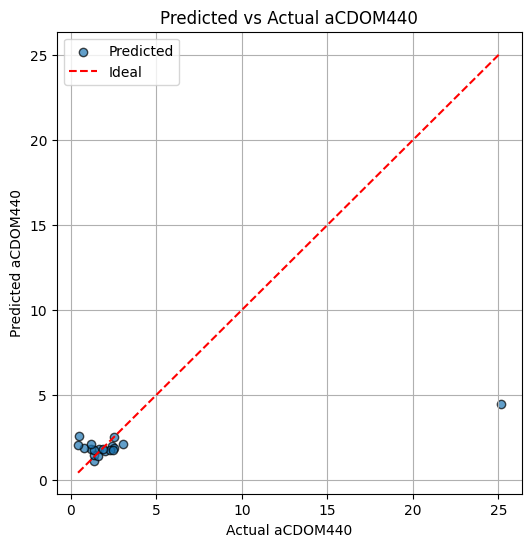

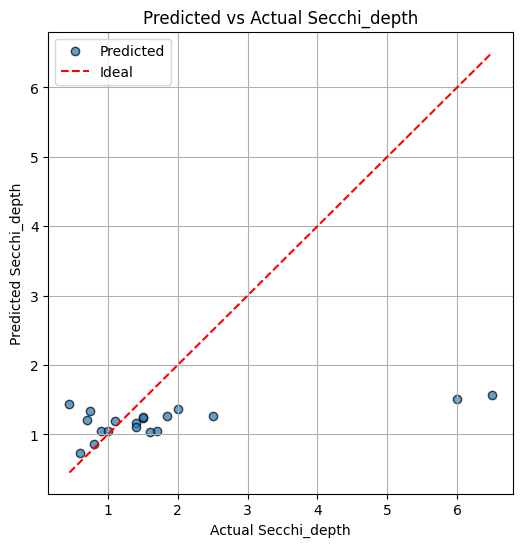

In [2]:
import matplotlib.pyplot as plt

# Define y_pred using your CNN-only model. (Make sure X_test_cnn is correctly reshaped for your CNN input.)
y_pred = model.predict(X_test_cnn)

# Define the list of target parameter names.
target_columns = ['Chla', 'TSS', 'aCDOM440', 'Secchi_depth']

# Create individual scatter plots for each target.
for i, target in enumerate(target_columns):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test[:, i], y_pred[:, i], alpha=0.7, edgecolors='k', label="Predicted")
    plt.plot([y_test[:, i].min(), y_test[:, i].max()],
             [y_test[:, i].min(), y_test[:, i].max()], 'r--', label="Ideal")
    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"Predicted vs Actual {target}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [3]:

target_columns = ['Chla', 'TSS', 'aCDOM440', 'Secchi_depth']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


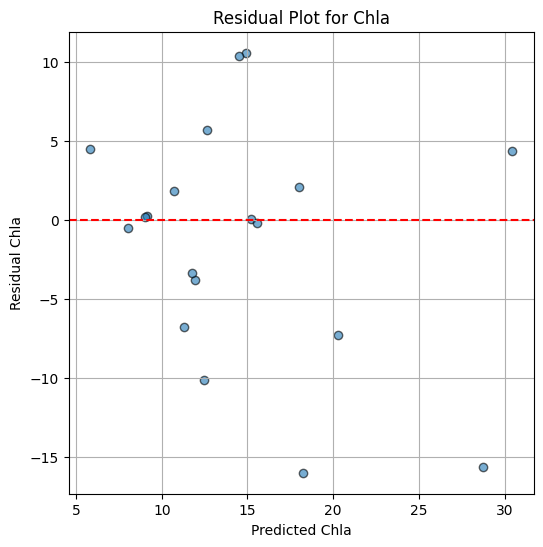

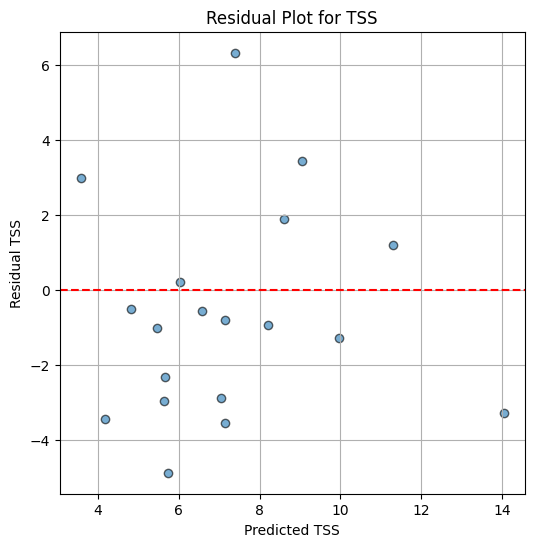

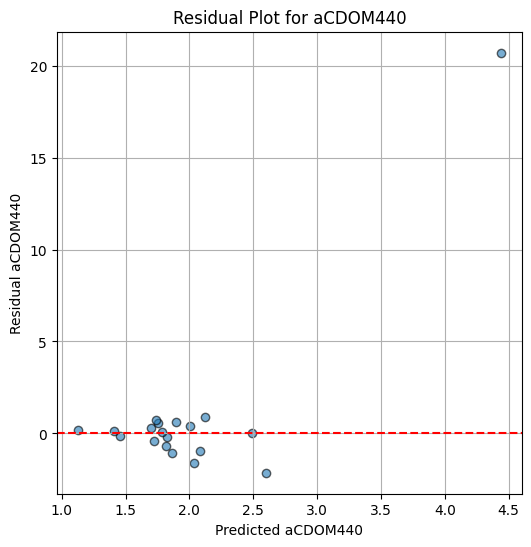

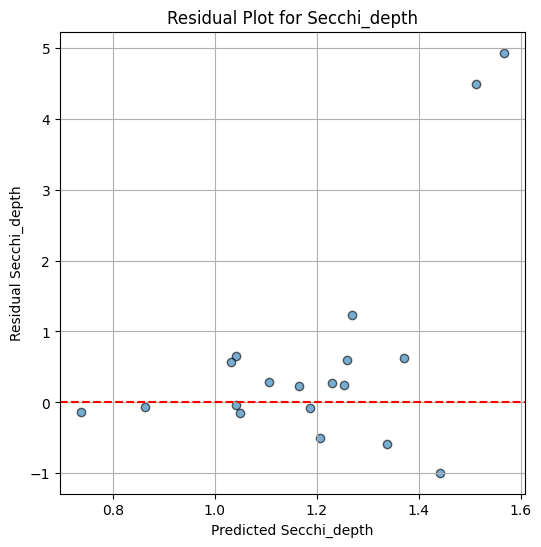

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
y_pred = model.predict(X_test_cnn)
residuals = y_test - y_pred

for i, target in enumerate(target_columns):
    plt.figure(figsize=(6,6))
    plt.scatter(y_pred[:, i], residuals[:, i], alpha=0.6, edgecolors='k')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel(f"Predicted {target}")
    plt.ylabel(f"Residual {target}")
    plt.title(f"Residual Plot for {target}")
    plt.grid(True)
    plt.show()


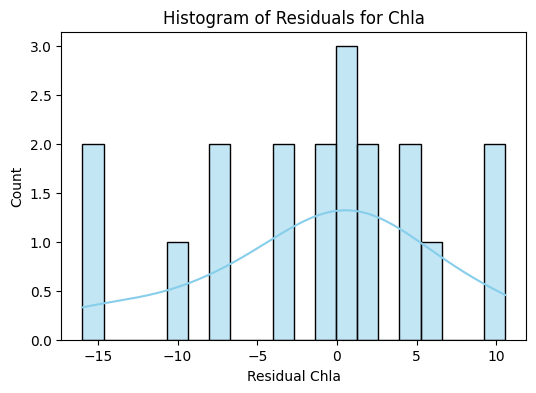

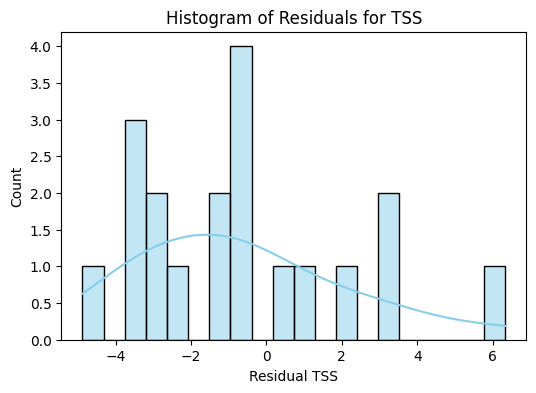

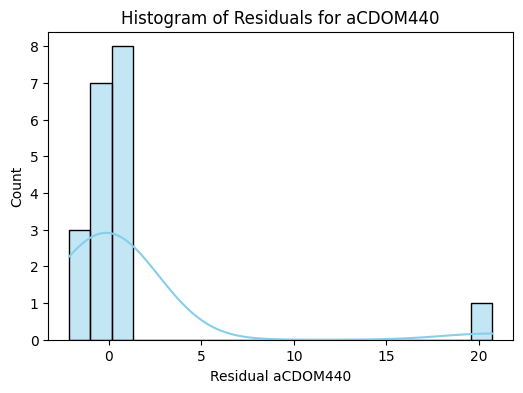

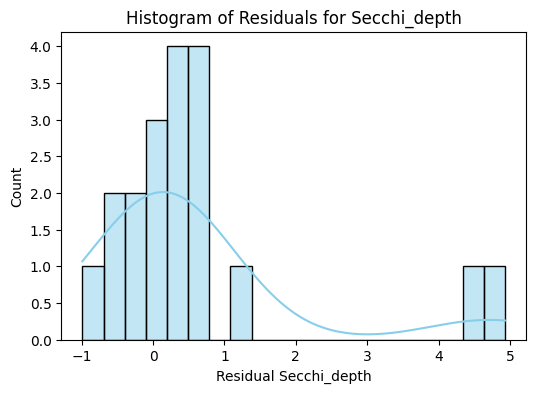

In [5]:
import seaborn as sns

for i, target in enumerate(target_columns):
    plt.figure(figsize=(6,4))
    sns.histplot(residuals[:, i], bins=20, kde=True, color='skyblue')
    plt.xlabel(f"Residual {target}")
    plt.title(f"Histogram of Residuals for {target}")
    plt.show()



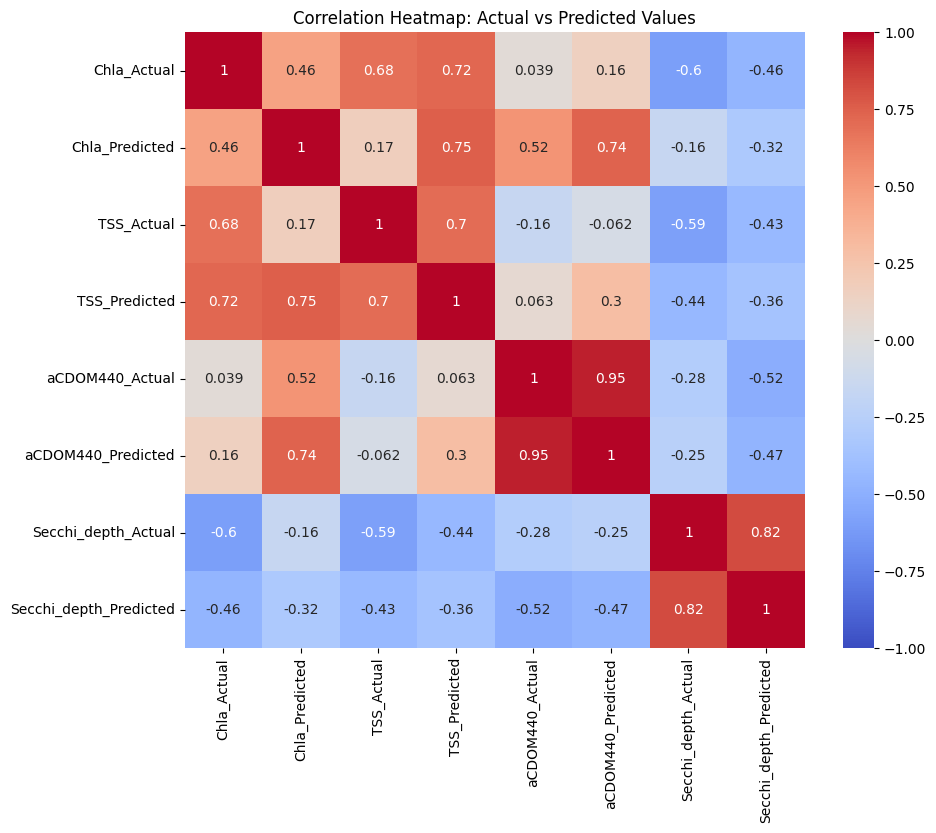

In [ ]:
# Combine actual and predicted values in one DataFrame
corr_data = {}
for i, target in enumerate(target_columns):
    corr_data[f"{target}_Actual"] = y_test[:, i]
    corr_data[f"{target}_Predicted"] = y_pred[:, i]

df_corr = pd.DataFrame(corr_data)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Actual vs Predicted Values")
plt.show()


In [ ]:
# Assuming X_test is your feature matrix
df_corr = pd.DataFrame(X_test, columns=[f"Rrs_{i}" for i in range(X_test.shape[1])])
df_corr["Residuals"] = residuals[:, 0]

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap Between Features and Residuals (Chla)")
plt.show()



KeyboardInterrupt: 

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Combine input features and target variables into one DataFrame
# Replace 'Rrs_443', 'Rrs_560', etc., with the actual feature names from your dataset
data = pd.DataFrame(X_test, columns=['Rrs_443', 'Rrs_560', 'Rrs_665', 'Rrs_705'])  # Add all Rrs_* columns
data['Chla'] = y_test[:, 0]
data['TSS'] = y_test[:, 1]
data['aCDOM440'] = y_test[:, 2]
data['Secchi_depth'] = y_test[:, 3]

# Create pair plot for all features and target variables
sns.pairplot(data, diag_kind='kde', corner=True)
plt.suptitle("Pair Plot of Features and Target Parameters", y=1.02)
plt.show()


NameError: name 'X_test' is not defined

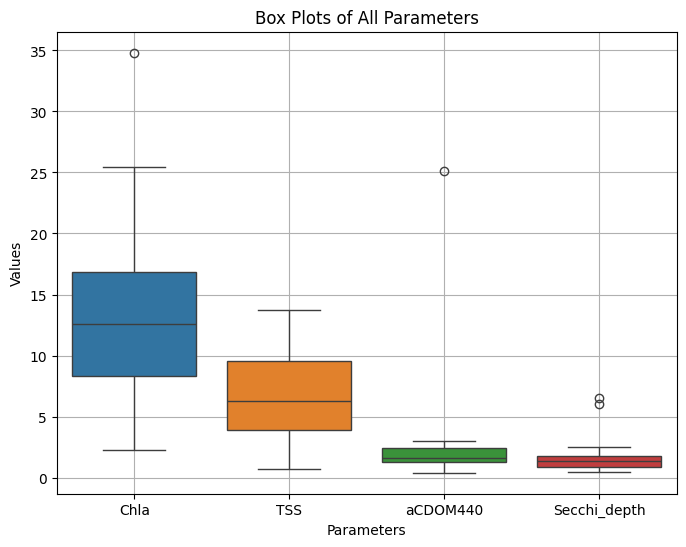

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Combine all target variables into a DataFrame
data = pd.DataFrame({
    'Chla': y_test[:, 0],
    'TSS': y_test[:, 1],
    'aCDOM440': y_test[:, 2],
    'Secchi_depth': y_test[:, 3]
})

# Create box plots for all parameters
plt.figure(figsize=(8, 6))
sns.boxplot(data=data)
plt.title("Box Plots of All Parameters")
plt.xlabel("Parameters")
plt.ylabel("Values")
plt.grid(True)
plt.show()


In [ ]:
# Import necessary libraries for testing
import os
import xarray as xr
import numpy as np

# ----------------------------------------------------------------
# Configuration: Adjust the following directory path as needed
# ----------------------------------------------------------------
# Directory containing the Sentinel-3 OLCI .nc files
olci_nc_directory = "C:/Users/BraedynM/Documents/Science Fair 2025/OLCI_dataset"  # Update this to your actual directory

# ----------------------------------------------------------------
# Retrieve a list of NetCDF files in the directory
# ----------------------------------------------------------------
try:
    nc_files = [f for f in os.listdir(olci_nc_directory) if f.endswith('.nc')]
except FileNotFoundError:
    raise FileNotFoundError(f"Directory '{olci_nc_directory}' not found. Please update the path.")

# ----------------------------------------------------------------
# Determine the expected number of features (number of spectral bands)
# based on the trained model's CNN input shape.
# For example, if the model was trained with inputs of shape (num_features, 1),
# then:
# ----------------------------------------------------------------
expected_n_features = model.input_shape[1]  # Number of spectral bands

print("\nTesting OLCI .nc files with the trained CNN model:")
for nc_file in nc_files:
    file_path = os.path.join(olci_nc_directory, nc_file)
    try:
        # Open the NetCDF file using xarray
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"Error opening '{nc_file}': {e}")
        continue

    # Check if the dataset contains a variable named "reflectance"
    if "reflectance" not in ds.variables:
        print(f"File '{nc_file}' does not contain a 'reflectance' variable. Skipping.")
        continue

    # Extract the reflectance values
    ref_vals = ds["reflectance"].values

    # If reflectance is multi-dimensional (e.g., from a spatial image), average spatial dimensions
    if ref_vals.ndim > 1:
        # Assume the last dimension corresponds to spectral bands; average over all other dimensions
        sample = np.mean(ref_vals, axis=tuple(range(ref_vals.ndim - 1)))
    else:
        sample = ref_vals

    # Verify the sample has the expected number of spectral bands/features
    if sample.shape[0] != expected_n_features:
        print(f"File '{nc_file}' has {sample.shape[0]} features; expected {expected_n_features}. Skipping.")
        continue

    # Scale the sample using the same scaler that was fitted during training;
    # reshape to (1, -1) since the scaler expects 2D input
    sample_scaled = scaler.transform(sample.reshape(1, -1))
    
    # Reshape the sample for the CNN model (i.e., add the channel dimension)
    sample_ready = sample_scaled.reshape(1, expected_n_features, 1)

    # Predict water quality parameters using the trained CNN model
    prediction = model.predict(sample_ready)
    print(f"File: {nc_file} --> Predicted water quality parameters: {prediction}")



Testing OLCI .nc files with the trained CNN model:
File 'geo_coordinates.nc' does not contain a 'reflectance' variable. Skipping.


c:\Users\BraedynM\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\namedarray\core.py:264: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
c:\Users\BraedynM\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\namedarray\core.py:264: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately t

File 'instrument_data.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa01_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa01_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa02_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa02_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa03_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa03_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa04_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa04_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa05_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa05_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa06_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa06_radiance_unc.nc' does not contain a 'reflec

In [ ]:
!pip install xarray


   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 15.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
